#  Import libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.data_loader import split_dataset
from torchvision.datasets import ImageFolder
import pandas as pd
import seaborn as sns



# Splitting Data

In [ ]:

data_raw = os.path.join(project_root, 'data')
data_processed = os.path.join(project_root, 'data', 'processed') 
split_dataset(raw_dir=data_raw, output_dir=data_processed)

 Dataset split completed!


# Classes Distribution

In [14]:

project_root = os.path.dirname(os.getcwd()) 

base_path = os.path.join(project_root, "data", "processed")

folders = ["train", "validation", "test"]

print(f"Checking path: {base_path}") 

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print(f"\nFolder: {folder}")

    if not os.path.exists(folder_path):
        print(f" Folder does not exist! Searched at: {folder_path}")
        continue

    classes = os.listdir(folder_path)
    classes = [c for c in classes if os.path.isdir(os.path.join(folder_path, c))]
    
    print(f" Number of classes: {len(classes)}")

    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        num_images = len(os.listdir(class_path))
        print(f"    Class '{class_name}' : {num_images} images")

Checking path: c:\Users\Aya Mohamed\Documents\college\NN\Corn Disease\data\processed

Folder: train
 Number of classes: 4
    Class 'Blight' : 193 images
    Class 'Common_Rust' : 79 images
    Class 'Gray_Leaf_Spot' : 89 images
    Class 'Healthy' : 798 images

Folder: validation
 Number of classes: 4
    Class 'Blight' : 41 images
    Class 'Common_Rust' : 17 images
    Class 'Gray_Leaf_Spot' : 19 images
    Class 'Healthy' : 171 images

Folder: test
 Number of classes: 4
    Class 'Blight' : 42 images
    Class 'Common_Rust' : 18 images
    Class 'Gray_Leaf_Spot' : 20 images
    Class 'Healthy' : 172 images


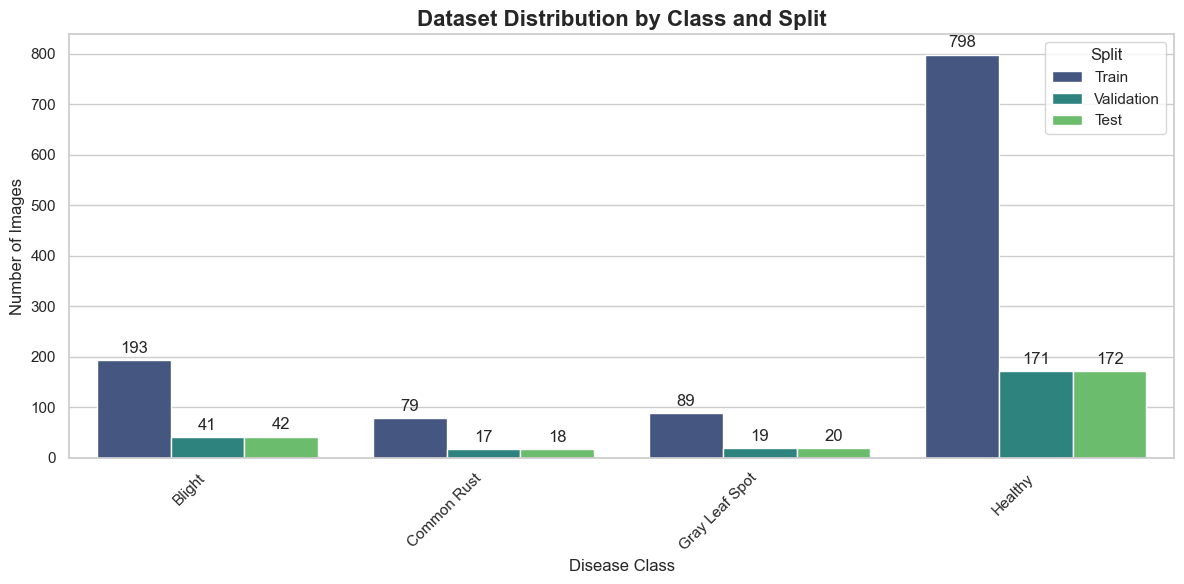

In [16]:


data = []
folders = ["train", "validation", "test"] 
base_path = os.path.join(os.path.dirname(os.getcwd()), "data", "processed")

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path): continue
    
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            data.append({
                "Folder": folder.capitalize(), 
                "Class": class_name.replace("_", " "), 
                "Images": num_images
            })

df = pd.DataFrame(data)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))


ax = sns.barplot(data=df, x="Class", y="Images", hue="Folder", palette="viridis")

plt.title("Dataset Distribution by Class and Split", fontsize=16, fontweight='bold')
plt.xlabel("Disease Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.legend(title="Split")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()